# 1. Data Exploration

This notebook explores the textual data used in the project.  
The analysis focuses on political manifestos from the French legislative elections of 1988, extracted from the Archelec corpus.

The goal is to understand the basic structure of the corpus before applying NLP models.

In [1]:
from google.colab import files

uploaded = files.upload()

Saving legislatives (1).zip to legislatives (1).zip


## 1.1 Extracting the dataset

The dataset is uploaded as a zip file and extracted inside the Colab environment.

In [2]:
import zipfile
import os

zip_path = "/content/legislatives (1).zip"  # change this if your uploaded file has a different name

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

print("Extraction completed.")

Extraction completed.


In [3]:
os.listdir("/content")

['.config', 'legislatives (1).zip', 'text_files', 'sample_data']

## 1.2 Loading text files

Each manifesto is stored as a `.txt` file.  
We load all text files into a pandas DataFrame with two columns:

- `id`: file name
- `text`: manifesto content

In [4]:
import pandas as pd

folder = "/content/text_files/1988/legislatives"

data = []

for filename in os.listdir(folder):
    if filename.endswith(".txt"):
        file_path = os.path.join(folder, filename)

        with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()

        data.append({
            "id": filename,
            "text": text
        })

df = pd.DataFrame(data)

print("Number of documents:", len(df))
df.head()

Number of documents: 3628


,id,text
0,EL176_L_1988_06_060_06_1_PF_01.txt,DEPARTEMENT DE L'OISE\n6ème CIRCONSCRIPTION\nC...
1,EL177_L_1988_06_095_07_1_PF_03.txt,LA FRANCE UNIE\nAVEC\nSciences Po / fonds CEVI...
2,EL175_L_1988_06_034_01_1_PF_04.txt,Sciences Po / fonds CEVIPOF\nELECTIONS LEGISLA...
3,EL177_L_1988_06_095_03_2_PF_01.txt,Sciences Po / fonds CEVIPOF\nElections législa...
4,EL176_L_1988_06_059_12_1_PF_03.txt,Sciences Po / fonds CEVIPOF\nELECTIONS LEGISLA...


## 1.3 Basic corpus statistics

We compute basic statistics to understand the size and structure of the corpus.

In [5]:
df["num_characters"] = df["text"].apply(len)
df["num_words"] = df["text"].apply(lambda x: len(x.split()))
df["num_lines"] = df["text"].apply(lambda x: len(x.splitlines()))

df[["num_characters", "num_words", "num_lines"]].describe()

,num_characters,num_words,num_lines
count,3628.000000,3628.000000,3628.000000
mean,3446.140849,551.820011,32.327729
std,1632.790490,264.045134,12.680865
min,63.000000,9.000000,3.000000
25%,2404.000000,382.000000,25.000000
50%,3068.000000,495.000000,30.000000
75%,4236.250000,684.250000,37.000000
max,15489.000000,2552.000000,228.000000


## 1.4 Document length distribution

Document length is important because very short or very long documents may affect NLP representations and similarity scores.

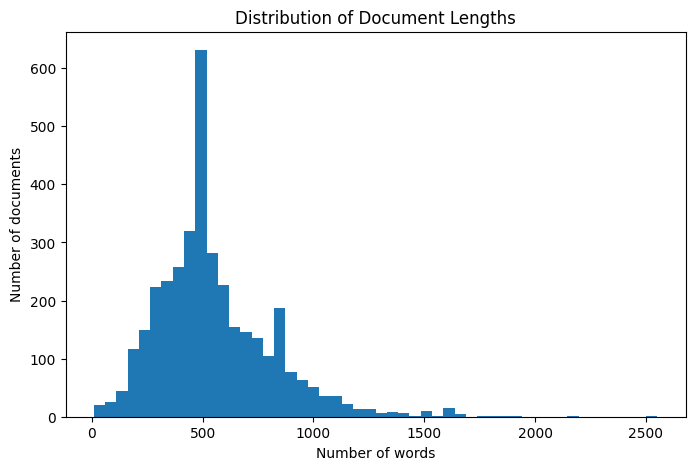

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["num_words"], bins=50)
plt.title("Distribution of Document Lengths")
plt.xlabel("Number of words")
plt.ylabel("Number of documents")
plt.show()

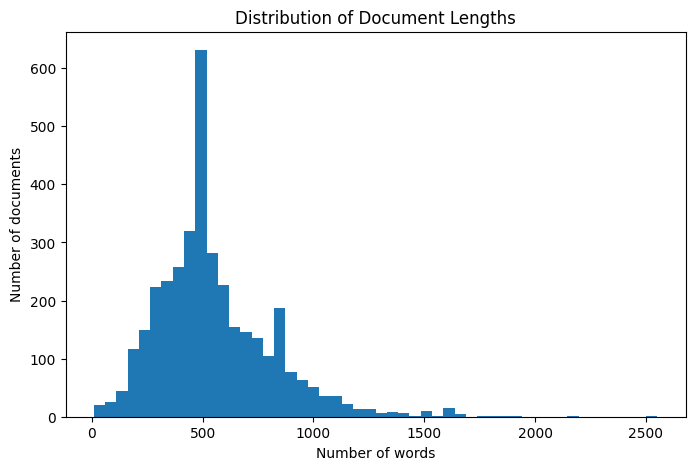

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(df["num_words"], bins=50)
plt.title("Distribution of Document Lengths")
plt.xlabel("Number of words")
plt.ylabel("Number of documents")
plt.savefig("length_plot.png", dpi=300, bbox_inches="tight")
plt.show()

## 1.5 Shortest and longest documents

We inspect the shortest and longest documents to identify potential OCR problems or unusual texts.

In [8]:
df.sort_values("num_words").head(10)[["id", "num_words", "num_characters"]]

,id,num_words,num_characters
1474,EL177_L_1988_06_075_08_1_BV_pdfmasterocr.txt,9,63
3416,EL176_L_1988_06_066_03_1_BV_pdfmasterocr.txt,16,92
3157,EL177_L_1988_06_075_19_1_BV_pdfmasterocr.txt,18,134
3076,EL177_L_1988_06_075_12_1_BV_pdfmasterocr.txt,18,137
712,EL177_L_1988_06_075_18_1_BV_pdfmasterocr.txt,18,140
3083,EL177_L_1988_06_075_03_1_BV_pdfmasterocr.txt,18,133
928,EL177_L_1988_06_075_13_1_BV_pdfmasterocr.txt,19,133
512,EL177_L_1988_06_075_21_1_BV_pdfmasterocr.txt,19,132
2527,EL177_L_1988_06_075_14_1_BV_pdfmasterocr.txt,21,153
663,EL176_L_1988_06_059_16_2_BV_pdfmasterocr.txt,25,180


In [9]:
df.sort_values("num_words", ascending=False).head(10)[["id", "num_words", "num_characters"]]

,id,num_words,num_characters
112,EL174_L_1988_06_006_08_1_PF_02.txt,2552,15489
2349,EL175_L_1988_06_031_03_1_PF_03.txt,2160,13961
1241,EL177_L_1988_06_094_07_1_PF_03.txt,1939,11764
533,EL177_L_1988_06_974_05_1_PF_03.txt,1853,12086
1615,EL175_L_1988_06_038_02_1_PF_pdfmasterocr.txt,1817,11571
1722,EL177_L_1988_06_094_07_1_PF_01.txt,1794,11413
172,EL176_L_1988_06_068_06_2_PF_01.txt,1782,11148
111,EL176_L_1988_06_067_04_1_PF_01.txt,1663,10998
2663,EL174_L_1988_06_012_03_1_PF_03.txt,1653,9845
2059,EL174_L_1988_06_013_16_1_PF_05.txt,1648,10475


## 1.6 Average document length

We compute average and median document length.  
The median is useful because the distribution may be skewed by very long documents.

In [10]:
mean_words = df["num_words"].mean()
median_words = df["num_words"].median()
min_words = df["num_words"].min()
max_words = df["num_words"].max()

print("Mean number of words:", round(mean_words, 2))
print("Median number of words:", median_words)
print("Minimum number of words:", min_words)
print("Maximum number of words:", max_words)

Mean number of words: 551.82
Median number of words: 495.0
Minimum number of words: 9
Maximum number of words: 2552


## 1.7 Empty or very short documents

Very short documents may indicate OCR errors or incomplete files.  
We identify documents with fewer than 50 words.

In [11]:
short_docs = df[df["num_words"] < 50]

print("Number of very short documents:", len(short_docs))
short_docs[["id", "num_words", "text"]].head()

Number of very short documents: 16


,id,num_words,text
249,EL176_L_1988_06_059_10_2_BV_pdfmasterocr.txt,37,Sciences Po / fonds CEVIPOV\n10e Circonscripti...
512,EL177_L_1988_06_075_21_1_BV_pdfmasterocr.txt,19,Sciences Po / fonds CEVIPOV\nDépartement : PAR...
663,EL176_L_1988_06_059_16_2_BV_pdfmasterocr.txt,25,ÉLECTIONS LÉGISLATIVES JUIN 1988 XVI CIRCONSCR...
712,EL177_L_1988_06_075_18_1_BV_pdfmasterocr.txt,18,Département : PARIS 18ème Circonscription\nSyl...
928,EL177_L_1988_06_075_13_1_BV_pdfmasterocr.txt,19,Sciences Po / fonds CEVIPOV\nDépartement : PAR...


## 1.8 Cleaning preview

Before applying NLP models, we define a simple cleaning function and compare raw and cleaned text.

In [12]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

df[["id", "text", "clean_text"]].head()

,id,text,clean_text
0,EL176_L_1988_06_060_06_1_PF_01.txt,DEPARTEMENT DE L'OISE\n6ème CIRCONSCRIPTION\nC...,departement de l oise ème circonscription comp...
1,EL177_L_1988_06_095_07_1_PF_03.txt,LA FRANCE UNIE\nAVEC\nSciences Po / fonds CEVI...,la france unie avec sciences po fonds cevipof ...
2,EL175_L_1988_06_034_01_1_PF_04.txt,Sciences Po / fonds CEVIPOF\nELECTIONS LEGISLA...,sciences po fonds cevipof elections legislativ...
3,EL177_L_1988_06_095_03_2_PF_01.txt,Sciences Po / fonds CEVIPOF\nElections législa...,sciences po fonds cevipof elections législativ...
4,EL176_L_1988_06_059_12_1_PF_03.txt,Sciences Po / fonds CEVIPOF\nELECTIONS LEGISLA...,sciences po fonds cevipof elections legislativ...


## 1.9 Vocabulary size

We estimate the number of unique words before and after cleaning.

In [13]:
raw_vocab = set(" ".join(df["text"]).split())
clean_vocab = set(" ".join(df["clean_text"]).split())

print("Raw vocabulary size:", len(raw_vocab))
print("Cleaned vocabulary size:", len(clean_vocab))

Raw vocabulary size: 96753
Cleaned vocabulary size: 45429


## 1.10 Most frequent words

We inspect the most frequent words in the cleaned corpus.  
This provides a first overview of recurrent vocabulary in the manifestos.

In [14]:
from collections import Counter

all_words = " ".join(df["clean_text"]).split()
word_counts = Counter(all_words)

word_counts.most_common(30)

[('de', 106904),
 ('la', 66712),
 ('et', 57951),
 ('le', 47506),
 ('l', 46671),
 ('les', 39795),
 ('à', 36985),
 ('pour', 35475),
 ('des', 32470),
 ('du', 27598),
 ('d', 27366),
 ('qui', 19085),
 ('en', 18147),
 ('une', 16534),
 ('vous', 15368),
 ('est', 15240),
 ('que', 14557),
 ('nous', 12263),
 ('un', 12210),
 ('dans', 11989),
 ('au', 11360),
 ('par', 10578),
 ('je', 10476),
 ('a', 9934),
 ('il', 9496),
 ('avec', 9013),
 ('notre', 8359),
 ('france', 8310),
 ('c', 8268),
 ('pas', 7809)]

## 1.11 Word frequency visualization

We visualize the most frequent words in the corpus.

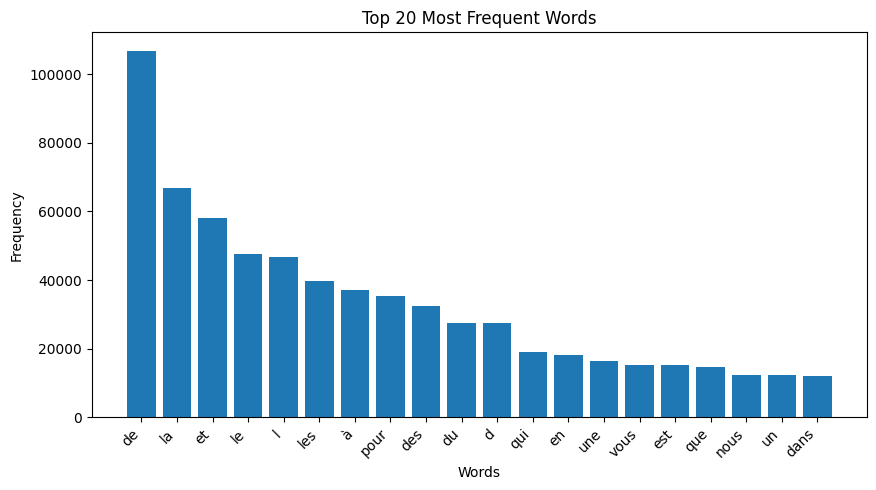

In [15]:
top_words = word_counts.most_common(20)

words = [w for w, c in top_words]
counts = [c for w, c in top_words]

plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.show()

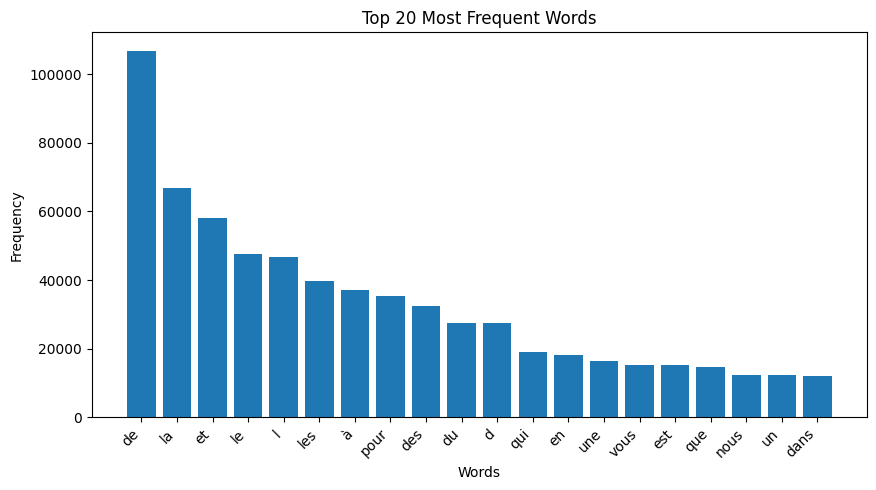

In [16]:
plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.savefig("top_words_plot.png", dpi=300, bbox_inches="tight")
plt.show()

## 1.12 Summary

This exploratory analysis shows that the corpus contains several thousand manifestos with heterogeneous document lengths.  
Some documents are very short, which may reflect incomplete OCR transcriptions or unusual manifesto formats.  
The cleaned vocabulary remains large, suggesting substantial lexical diversity across the corpus.

These observations justify the need for both lexical and semantic NLP methods in the next stages of the project.